In [1]:
# load libraries
import pandas as pd 
from mbiomekit.group_comparison import analysis, plotter
from mbiomekit.picrust import picrust_pathway

In [2]:
pathway = pd.read_csv('data/2-processed/amplicon/picrust/pathways_out/path_abun_unstrat.tsv', sep='\t', header=0, index_col=0)
pathway.to_csv('data/pathway.tsv')

# Load data 
group = pd.read_csv('data/group.tsv', sep='\t', header=0, index_col=0)
enterotype = pd.read_csv('data/enterotype.tsv', sep='\t', header=0, index_col=0)

In [3]:
grp_map = {}
for sid, g in group['group1'].items():
    grp_map[sid] = g

In [4]:
# Statistical test 
an = analysis.Analyzer()
an.set_feature_table(pathway)
an.set_group(group.loc[:, 'group1'])
an.group_analysis()
an.save_results('data/3-results/group_comparison/kruskal_pathway.tsv', 'data/3-results/group_comparison/dunn_pathway.json')

In [5]:
# Load data 
group = pd.read_csv('data/group.tsv', sep='\t', header=0, index_col=0)
enterotype = pd.read_csv('data/enterotype.tsv', sep='\t', header=0, index_col=0)

pp = picrust_pathway.PicrustPathway()
pp.load_pathway('data/pathway.tsv')
pp.rename_index_by_pathway_name()
pathway = pp.pathway

                                                            CT1         CT10  \
pathway                                                                        
N10-formyl-tetrahydrofolate biosynthesis            7134.466772  6443.970945   
4-hydroxyphenylacetate degradation                     7.151765     1.097312   
aerobactin biosynthesis                                0.000000     0.000000   
superpathway of chorismate metabolism                105.411596    76.717999   
homolactic fermentation                             6489.126652  6144.556973   
...                                                         ...          ...   
L-tyrosine degradation I                               0.000000     0.000000   
superpathway of ubiquinol-8 biosynthesis (proka...    52.519528    30.228994   
UDP-N-acetyl-D-glucosamine biosynthesis I           6114.415243  6049.159109   
L-valine degradation I                                 0.000000     0.000000   
L-valine biosynthesis                   

In [6]:
# Statistical test 
an = analysis.Analyzer()
an.set_feature_table(pathway)
an.set_group(group.loc[:, 'group1'])
an.group_analysis()


In [7]:
id_sel = an.result_kruskal.index[an.result_kruskal['adjusted-p'] < 0.05][:15]
pathway_sel = pathway.loc[id_sel, :]

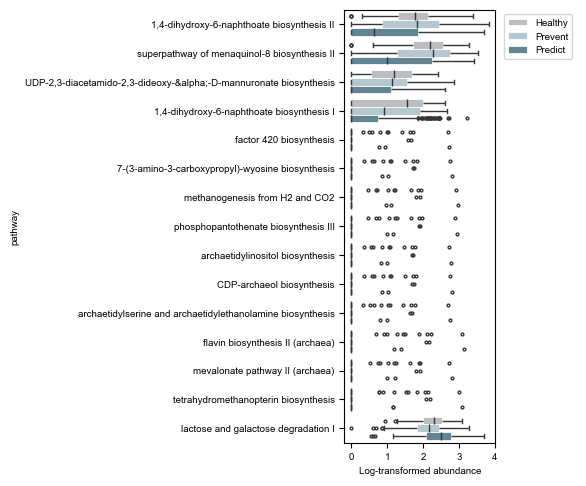

In [8]:
palette = {'Healthy': '#aaadb2',
           'Prevent': '#9fbcca',
           'Predict': '#326a81'}
pt = plotter.Plotter()
pt.plot_microbe_abundance(pathway_sel, fout='figures/group_comparison/kw_dunn_pathway.pdf', palette=palette, group_map   =grp_map, label='pathway', hue_order=['Healthy', 'Prevent', 'Predict']) 

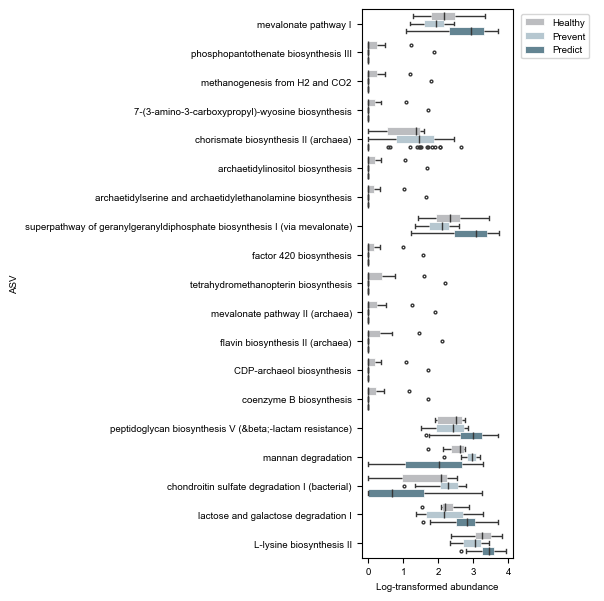

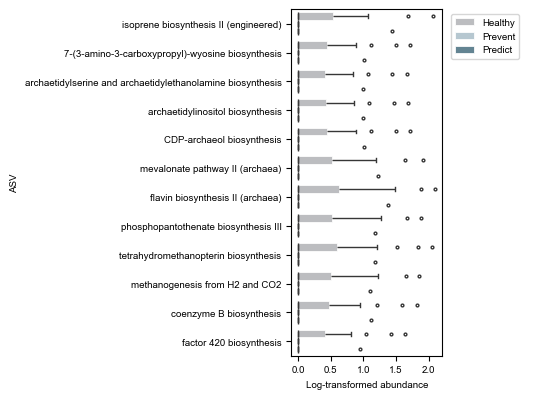

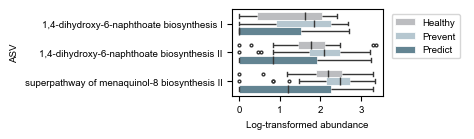

In [9]:
# Statistical test for each cluster 
dp = {}
for c in [0, 1, 3]:
    idx = enterotype.index[enterotype['cluster'] == c]
    pathway_cl = pathway.loc[:, idx]
    group_cl = group.loc[idx, :]
    
    an = analysis.Analyzer()
    an.set_feature_table(pathway_cl)
    an.set_group(group_cl.loc[:, 'group1'])
    an.group_analysis()
    an.save_results(f'data/3-results/group_comparison/kruskal_pathway_cl{c}.tsv', f'data/3-results/group_comparison/dunn_pathway_cl{c}.json')
    
    id_sel = an.result_kruskal.index[an.result_kruskal['adjusted-p'] < 0.05][:20]
    pathway_sel = pathway_cl.loc[id_sel, :]
    
    dp[c] = set(id_sel)
    
    pt = plotter.Plotter()
    pt.plot_microbe_abundance(pathway_sel, fout=f'figures/group_comparison/kw_dunn_pathway_cl{c}.pdf', palette=palette, group_map=grp_map, label='ASV', hue_order=['Healthy', 'Prevent', 'Predict'])
    